In [8]:
import time

import matplotlib.pyplot as plt

from utils import ImageGen
from path import findPath
from sokoban import findSolution
from constants import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
env = [
  [0, 0, 0, 0],
  [0, 1, 0, 0],
  [2, 1, 0, 0],
  [0, 1, 0, 0],
]

steps = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
times = []

for step in steps:
  t1 = time.time()
  positions = findPath(env, 6, step)
  t2 = time.time()
  
  dt = t2 - t1
  
  times.append(dt)
  print(f'step={step}: {dt}s')
  print(f'step={step} actual number of steps: {len(positions)}')

step=5: 0.03792619705200195s
step=5 actual number of steps: 6
step=10: 0.0522310733795166s
step=10 actual number of steps: 11
step=15: 0.08111310005187988s
step=15 actual number of steps: 16
step=20: 0.12081408500671387s
step=20 actual number of steps: 11
step=25: 0.17853689193725586s
step=25 actual number of steps: 14
step=30: 0.23673200607299805s
step=30 actual number of steps: 2
step=35: 0.3407740592956543s
step=35 actual number of steps: 26
step=40: 0.38475894927978516s
step=40 actual number of steps: 2
step=45: 0.4992549419403076s
step=45 actual number of steps: 2
step=50: 0.587332010269165s
step=50 actual number of steps: 2


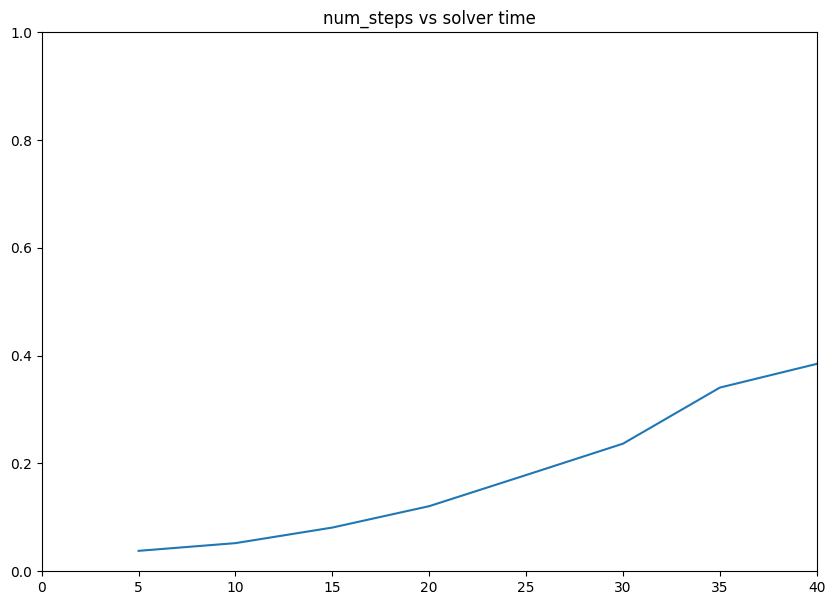

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(steps, times)
ax.set_title('num_steps vs solver time')
ax.set_xbound(0, 40)
ax.set_ybound(0, 1)

Visualization

In [12]:
def plot(model, n, k):
  assert model != None
  
  image_gen = ImageGen()
  imgs = image_gen.generate_sequence(model, n, k, )

  fig, ax = plt.subplots(ncols = k+1, figsize=(12, 5))

  for i in range(k+1):
    ax[i].imshow(imgs[i], interpolation='nearest')
    ax[i].axes.xaxis.set_visible(False)
    ax[i].axes.yaxis.set_visible(False)
    ax[i].set_title(f'step_{i}')

  plt.show()

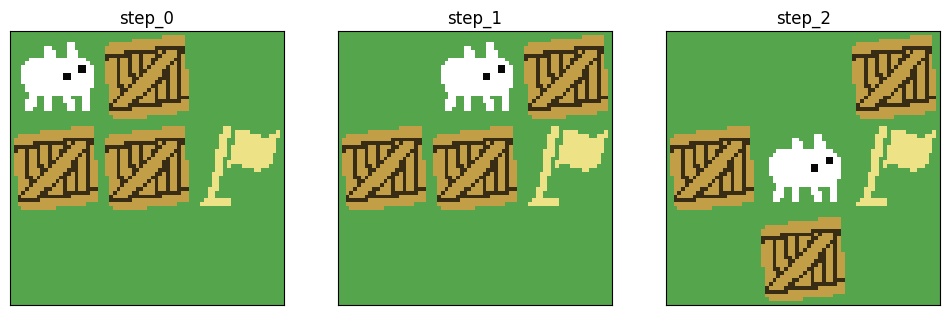

In [13]:
env = [
    [0, 3, 0],
    [3, 3, 1],
    [0, 0, 0],
]
n = len(env)
k = 2

model = findSolution(env, 0, k, r=5)

plot(model, n, k)

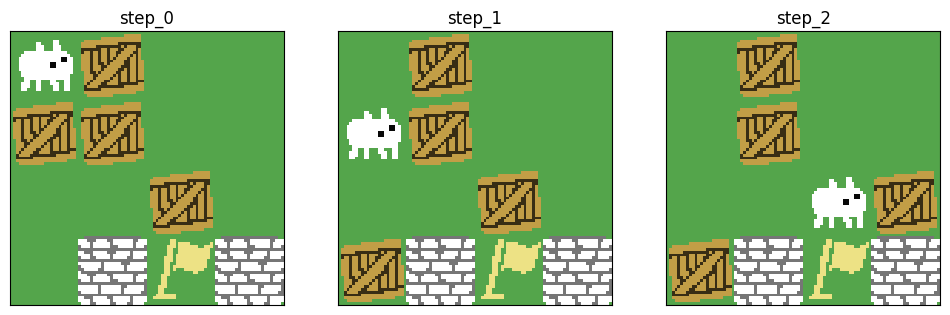

In [15]:
env = [
    [EMPTY ,BOX   ,EMPTY ,EMPTY],
    [BOX   ,BOX   ,EMPTY ,EMPTY],
    [EMPTY ,EMPTY ,BOX   ,EMPTY],
    [EMPTY ,WALL  ,GOAL  ,WALL],
]
n = len(env)
k = 2

model = findSolution(env, 0, k, r=3)

if model != None:
  plot(model, n, k)

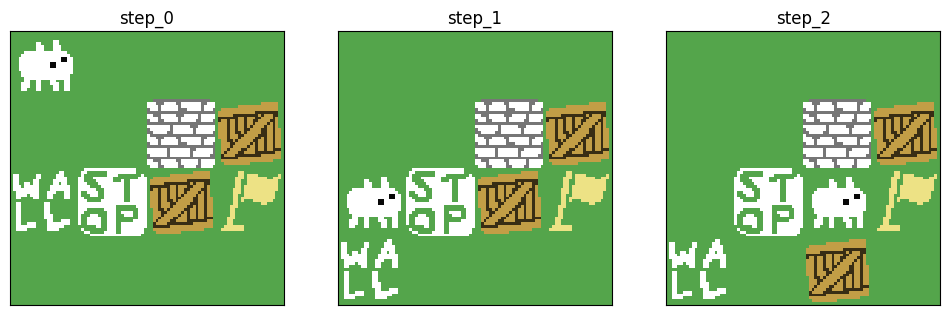

In [16]:
env = [
    [EMPTY    , EMPTY   , EMPTY , EMPTY],
    [EMPTY    , EMPTY   , WALL  , BOX],
    [WALL_TXT , STOP_TXT, BOX   , GOAL],
    [EMPTY    , EMPTY   , EMPTY , EMPTY],
]

n = len(env)
k = 2

model = findSolution(env, 0, k, r=3)

if model != None:
  plot(model, n, k)